In [3]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv("../../data/data_roles_final.csv")
df_ml=df[
    df['salary_final'].notna()&
    (df['salary_final']>20000)&
    (df['salary_final']<400000)
].copy()
print("ML datset shape:",df_ml.shape)
print("Columns:",df_ml.columns.tolist())

ML datset shape: (2854, 30)
Columns: ['company_name', 'title', 'description', 'max_salary', 'location', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'formatted_experience_level', 'skills_desc', 'listed_time', 'work_type', 'normalized_salary', 'salary', 'city', 'state', 'salary_bracket', 'is_data_role', 'listed_date', 'year', 'month', 'salary_clean', 'salary_from_range', 'salary_final', 'listed_date_fixed', 'week']


Target variable


In [5]:
# Target — Salary Bracket (what we want to predict)
def salary_bracket(sal):
    if sal < 60000:
        return 'Low'
    elif sal < 120000:
        return 'Mid'
    else:
        return 'High'

df_ml['target'] = df_ml['salary_final'].apply(salary_bracket)

print("Target distribution:")
print(df_ml['target'].value_counts())
print("\nTarget %:")
print((df_ml['target'].value_counts() / 
       len(df_ml) * 100).round(1))

Target distribution:
target
Mid     1530
High    1064
Low      260
Name: count, dtype: int64

Target %:
target
Mid     53.6
High    37.3
Low      9.1
Name: count, dtype: float64


Create Features

In [6]:
# ── Feature 1: Is Remote ──
df_ml['is_remote'] = df_ml['remote_allowed'].fillna(0).astype(int)

# ── Feature 2: Is Full Time ──
df_ml['is_fulltime'] = (
    df_ml['formatted_work_type'] == 'Full-time'
).astype(int)

# ── Feature 3: Experience Level Encoded ──
exp_map = {
    'Internship': 0,
    'Entry level': 1,
    'Associate': 2,
    'Mid-Senior level': 3,
    'Director': 4,
    'Executive': 5,
    'Not Specified': 1  # assume entry
}
df_ml['exp_encoded'] = df_ml[
    'formatted_experience_level'
].map(exp_map).fillna(1)

# ── Feature 4: Job Title Category ──
def categorize_title(title):
    title = str(title).lower()
    if 'data scientist' in title:
        return 'data_scientist'
    elif 'data engineer' in title:
        return 'data_engineer'
    elif 'data analyst' in title:
        return 'data_analyst'
    elif 'business analyst' in title:
        return 'business_analyst'
    elif 'financial analyst' in title:
        return 'financial_analyst'
    elif 'machine learning' in title or 'ml' in title:
        return 'ml_engineer'
    elif 'director' in title:
        return 'director'
    elif 'senior' in title:
        return 'senior_role'
    elif 'manager' in title:
        return 'manager'
    else:
        return 'other'

df_ml['title_category'] = df_ml['title'].apply(categorize_title)
print("Title categories:\n", 
      df_ml['title_category'].value_counts())

# ── Feature 5: Has Skills Listed ──
df_ml['has_skills'] = (
    df_ml['skills_desc'].notna() & 
    (df_ml['skills_desc'] != '')
).astype(int)

# ── Feature 6: Skill Flags ──
skill_list = [
    'python', 'sql', 'excel', 'tableau',
    'power bi', 'machine learning', 'aws',
    'spark', 'r programming', 'statistics'
]

for skill in skill_list:
    col_name = 'skill_' + skill.replace(' ', '_')
    df_ml[col_name] = df_ml['description'].str.lower().str.contains(
        skill, na=False
    ).astype(int)

print("\nSkill features created!")
print("Sample skill counts:")
for skill in skill_list:
    col = 'skill_' + skill.replace(' ', '_')
    print(f"  {skill}: {df_ml[col].sum()} jobs")

# ── Feature 7: Views and Applies ──
df_ml['views'] = df_ml['views'].fillna(0)
df_ml['applies'] = df_ml['applies'].fillna(0)
df_ml['apply_rate'] = (
    df_ml['applies'] / 
    (df_ml['views'] + 1)  # +1 to avoid division by zero
).round(4)

print("\n✅ All features created!")
print("Total features:", df_ml.shape[1])

Title categories:
 title_category
other                1672
senior_role           325
business_analyst      145
financial_analyst     141
data_analyst          129
data_engineer         121
ml_engineer            93
manager                88
data_scientist         88
director               52
Name: count, dtype: int64

Skill features created!
Sample skill counts:
  python: 577 jobs
  sql: 748 jobs
  excel: 1677 jobs
  tableau: 288 jobs
  power bi: 197 jobs
  machine learning: 300 jobs
  aws: 598 jobs
  spark: 139 jobs
  r programming: 47 jobs
  statistics: 309 jobs

✅ All features created!
Total features: 47


Encode Categorical Features

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode title category
le_title = LabelEncoder()
df_ml['title_encoded'] = le_title.fit_transform(
    df_ml['title_category'])

print("Title encoding map:")
for i, cls in enumerate(le_title.classes_):
    print(f"  {cls} → {i}")

Title encoding map:
  business_analyst → 0
  data_analyst → 1
  data_engineer → 2
  data_scientist → 3
  director → 4
  financial_analyst → 5
  manager → 6
  ml_engineer → 7
  other → 8
  senior_role → 9


 Select Final Features for ML

In [8]:
# Final feature list
feature_cols = [
    # Job characteristics
    'is_remote',
    'is_fulltime', 
    'exp_encoded',
    'title_encoded',
    'has_skills',
    'views',
    'applies',
    'apply_rate',
    # Skill flags
    'skill_python',
    'skill_sql',
    'skill_excel',
    'skill_tableau',
    'skill_power_bi',
    'skill_machine_learning',
    'skill_aws',
    'skill_spark',
    'skill_r_programming',
    'skill_statistics'
]

# Encode target
target_map = {'Low': 0, 'Mid': 1, 'High': 2}
df_ml['target_encoded'] = df_ml['target'].map(target_map)

# Final ML dataframe
X = df_ml[feature_cols].copy()
y = df_ml['target_encoded'].copy()

print("✅ Features shape:", X.shape)
print("✅ Target shape:", y.shape)
print("\nFeature list:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")
print("\nTarget distribution:")
print(y.value_counts().sort_index())
print("0 = Low salary, 1 = Mid salary, 2 = High salary")

✅ Features shape: (2854, 18)
✅ Target shape: (2854,)

Feature list:
  1. is_remote
  2. is_fulltime
  3. exp_encoded
  4. title_encoded
  5. has_skills
  6. views
  7. applies
  8. apply_rate
  9. skill_python
  10. skill_sql
  11. skill_excel
  12. skill_tableau
  13. skill_power_bi
  14. skill_machine_learning
  15. skill_aws
  16. skill_spark
  17. skill_r_programming
  18. skill_statistics

Target distribution:
target_encoded
0     260
1    1530
2    1064
Name: count, dtype: int64
0 = Low salary, 1 = Mid salary, 2 = High salary


Train Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducible results
    stratify=y          # balanced split
)

print("✅ Train/Test Split Complete!")
print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"\nTrain target distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest target distribution:")
print(y_test.value_counts().sort_index())

✅ Train/Test Split Complete!
Training set: (2283, 18)
Testing set:  (571, 18)

Train target distribution:
target_encoded
0     208
1    1224
2     851
Name: count, dtype: int64

Test target distribution:
target_encoded
0     52
1    306
2    213
Name: count, dtype: int64


Save ML Ready Data

In [12]:
import os

# Save everything
X_train.to_csv('../../data/X_train.csv', index=False)
X_test.to_csv('../../data/X_test.csv', index=False)
y_train.to_csv('../../data/y_train.csv', index=False)
y_test.to_csv('../../data/y_test.csv', index=False)

# Save full ML dataset
df_ml[feature_cols + ['target', 
      'target_encoded', 'salary_final',
      'title', 'company_name']].to_csv(
    '../../data/ml_ready.csv', index=False)

print("✅ All ML files saved!")
print("\nFiles created:")
print("  X_train.csv —", len(X_train), "rows")
print("  X_test.csv  —", len(X_test), "rows")
print("  y_train.csv —", len(y_train), "rows")
print("  y_test.csv  —", len(y_test), "rows")
print("  ml_ready.csv — full dataset")

✅ All ML files saved!

Files created:
  X_train.csv — 2283 rows
  X_test.csv  — 571 rows
  y_train.csv — 2283 rows
  y_test.csv  — 571 rows
  ml_ready.csv — full dataset


Quick Sanity Check

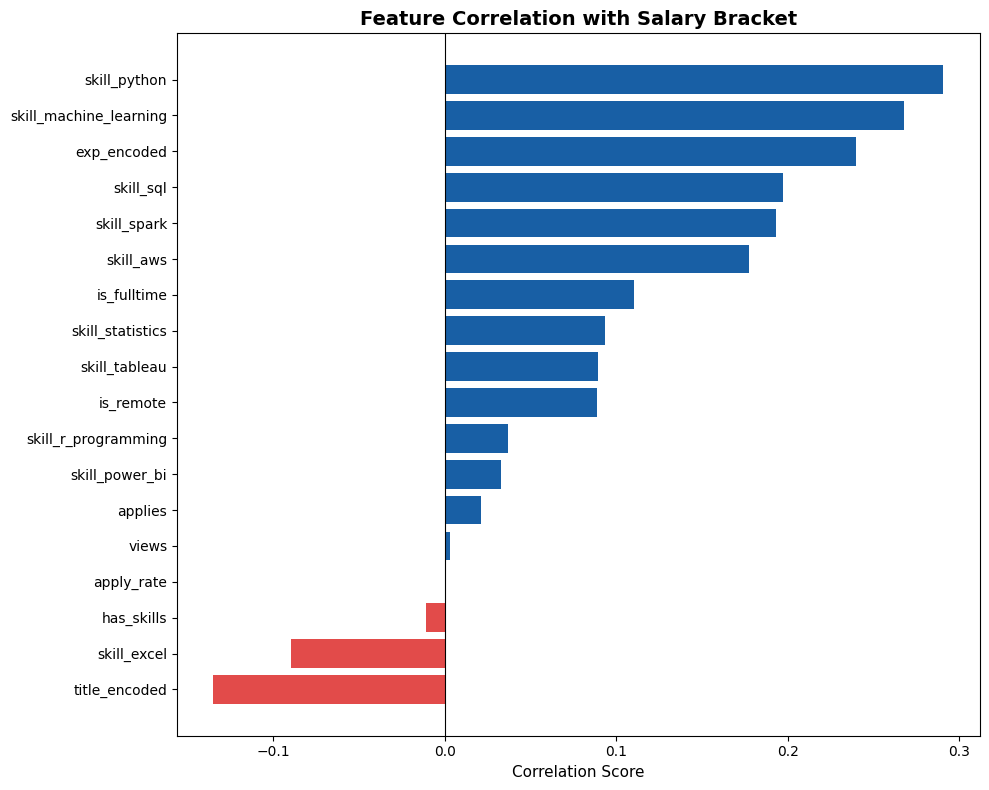

✅ Top 5 features correlated with salary:
skill_python              0.290913
skill_machine_learning    0.268044
exp_encoded               0.240117
skill_sql                 0.197466
skill_spark               0.193134
Name: salary_bracket, dtype: float64


In [14]:
# Correlation check — which features relate to salary?
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_train.copy()
corr['salary_bracket'] = y_train.values

correlation = corr.corr()['salary_bracket'].drop(
    'salary_bracket').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#185FA5' if x > 0 else '#E24B4A' 
          for x in correlation.values]
ax.barh(correlation.index[::-1],
        correlation.values[::-1],
        color=colors[::-1])
ax.set_title('Feature Correlation with Salary Bracket',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Score', fontsize=11)
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../../data/day6_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Top 5 features correlated with salary:")
print(correlation.abs().sort_values(
    ascending=False).head(5))